<a href="https://colab.research.google.com/github/MostaryKhatun/stress-depression-biomarker-discovery/blob/main/final_ROC_curve_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving GSE54566_matrix_Transpose_labeled.csv to GSE54566_matrix_Transpose_labeled.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 🔹 Step 1: Load Datasets
# ==============================
df1 = pd.read_csv('/content/GSE98793_matrix_Transpose_labeled.csv')
df2 = pd.read_csv('/content/GSE63878_matrix_Transpose_labeled.csv')
test_df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')

# ==============================
# 🔹 Step 2: Combine Train Data
# ==============================
train_df = pd.concat([df1, df2], axis=0)

# ==============================
# 🔹 Step 3: Column Format Fix
# ==============================
train_df.columns = train_df.columns.str.upper()
test_df.columns = test_df.columns.str.upper()

# ==============================
# 🔹 Step 4: Separate X, y
# ==============================
X_train = train_df.drop('TARGET', axis=1)
y_train = train_df['TARGET']

X_test = test_df.drop('TARGET', axis=1)
y_test = test_df['TARGET']

# ==============================
# 🔹 Step 5: Gene Matching
# ==============================
common_genes = list(set(X_train.columns) & set(X_test.columns))
print("Common genes:", len(common_genes))

X_train = X_train[common_genes]
X_test = X_test[common_genes]

# ==============================
# 🔹 Step 6: Handle Missing Values
# ==============================
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# ==============================
# 🔹 Step 7: Feature Selection 🔥
# ==============================
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=300)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# ==============================
# 🔹 Step 8: Scaling
# ==============================
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# ==============================
# 🔹 Step 9: Model (Tuned SVM)
# ==============================
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=200, gamma=0.0005, probability=True)
model.fit(X_train, y_train)

# ==============================
# 🔹 Step 10: Prediction
# ==============================
y_prob = model.predict_proba(X_test)[:,1]

# ==============================
# 🔹 Step 11: ROC + AUC
# ==============================
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("🔥 Validation AUC:", roc_auc)

# ==============================
# 🔹 Step 12: Plot ROC
# ==============================
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1], [0,1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Independent Validation')

plt.legend(loc='lower right')
plt.show()

🔥 AUC: 0.9985632183908046


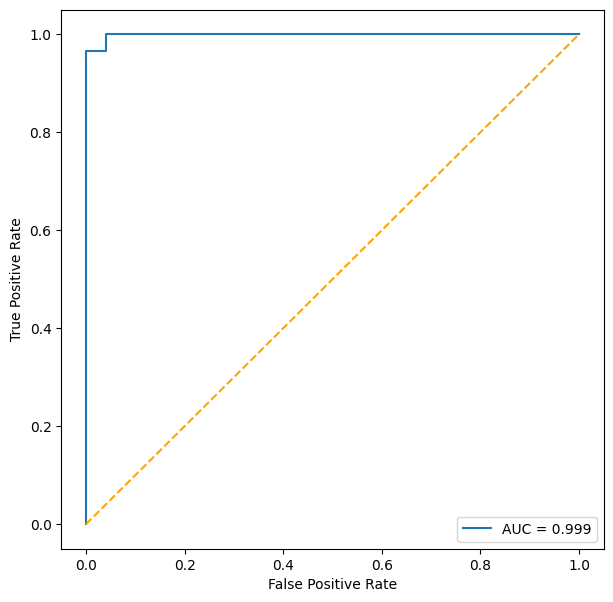

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE39653_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   # 🔥 weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

# 🔥 Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

External Validation Performance
AUC               : 0.9986
Sensitivity       : 0.9655
Specificity       : 0.9583
95% CI for AUC    : [0.9915, 1.0000]


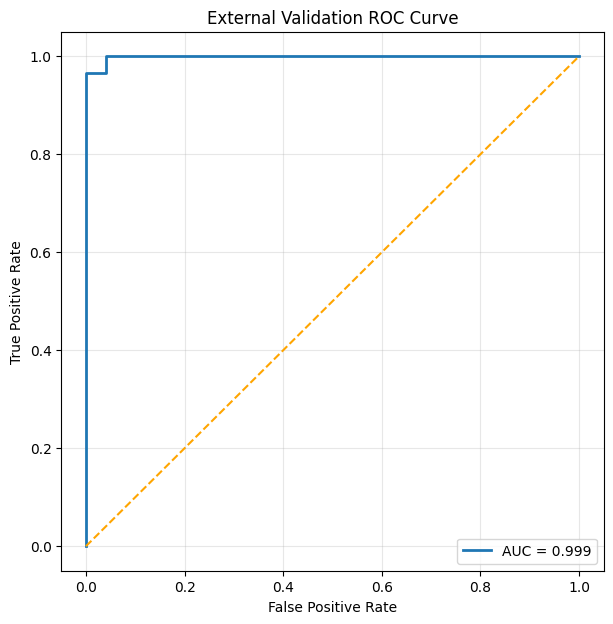

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    roc_auc_score
)

from scipy.stats import sem, t

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv('/content/GSE39653_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# ==========================================================
# Missing Values
# ==========================================================

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ==========================================================
# Feature Selection
# ==========================================================

selector = SelectKBest(
    score_func=f_classif,
    k=40
)

X = selector.fit_transform(X, y)

# ==========================================================
# Scaling
# ==========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================================
# Classifier
# ==========================================================

clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)

# ==========================================================
# Cross Validation
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Probability scores

y_prob = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method="predict_proba"
)[:,1]

# Predicted labels

y_pred = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method="predict"
)

# ==========================================================
# ROC
# ==========================================================

fpr, tpr, thresholds = roc_curve(y, y_prob)

roc_auc = auc(fpr, tpr)

# ==========================================================
# Sensitivity & Specificity
# ==========================================================

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

# ==========================================================
# 95% Confidence Interval (Bootstrap)
# ==========================================================

rng = np.random.RandomState(42)

bootstrapped_scores = []

for i in range(1000):

    indices = rng.randint(0, len(y), len(y))

    if len(np.unique(y[indices])) < 2:
        continue

    score = roc_auc_score(
        y[indices],
        y_prob[indices]
    )

    bootstrapped_scores.append(score)

bootstrapped_scores = np.array(bootstrapped_scores)

ci_lower = np.percentile(
    bootstrapped_scores,
    2.5
)

ci_upper = np.percentile(
    bootstrapped_scores,
    97.5
)

# ==========================================================
# Print Results
# ==========================================================

print("="*50)

print("External Validation Performance")

print("="*50)

print(f"AUC               : {roc_auc:.4f}")

print(f"Sensitivity       : {sensitivity:.4f}")

print(f"Specificity       : {specificity:.4f}")

print(f"95% CI for AUC    : [{ci_lower:.4f}, {ci_upper:.4f}]")

# ==========================================================
# ROC Plot
# ==========================================================

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='orange'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("External Validation ROC Curve")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

🔥 AUC: 0.9489795918367347


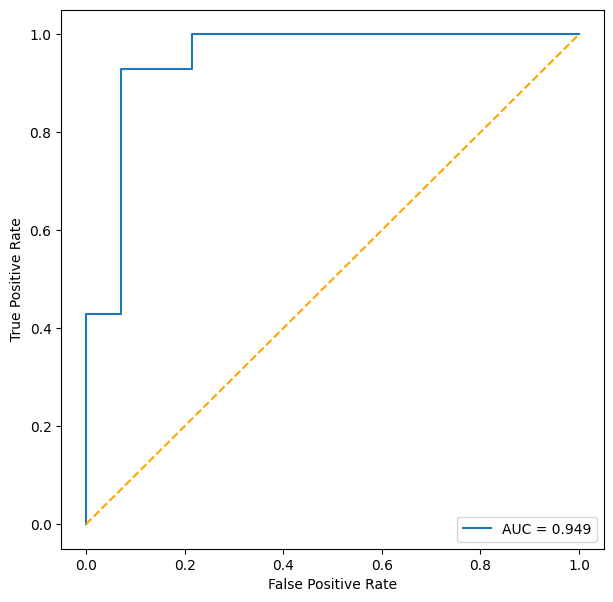

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE54566_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

#  Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

#  Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   #  weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

#  Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print(" AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

External Validation Performance (GSE54566)
AUC                 : 0.9439
Sensitivity         : 0.9286
Specificity         : 0.9286
95% CI for AUC      : [0.8385, 1.0000]


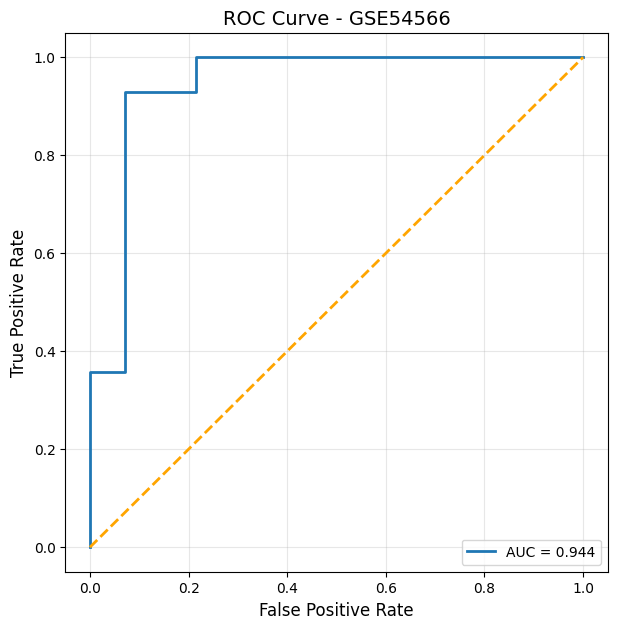

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    roc_auc_score
)

# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv('/content/GSE54566_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# ==========================================================
# Missing Value Imputation
# ==========================================================

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ==========================================================
# Feature Selection
# ==========================================================

selector = SelectKBest(
    score_func=f_classif,
    k=40
)

X = selector.fit_transform(X, y)

# ==========================================================
# Feature Scaling
# ==========================================================

scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================================
# Linear SVM Classifier
# ==========================================================

clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)

# ==========================================================
# 5-Fold Cross Validation
# ==========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Probability prediction

y_prob = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict_proba'
)[:,1]

# Predicted labels

y_pred = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict'
)

# ==========================================================
# ROC & AUC
# ==========================================================

fpr, tpr, thresholds = roc_curve(y, y_prob)

roc_auc = auc(fpr, tpr)

# ==========================================================
# Sensitivity & Specificity
# ==========================================================

tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

# ==========================================================
# Bootstrap 95% Confidence Interval
# ==========================================================

rng = np.random.RandomState(42)

boot_scores = []

for i in range(1000):

    indices = rng.randint(0, len(y), len(y))

    if len(np.unique(y[indices])) < 2:
        continue

    score = roc_auc_score(
        y[indices],
        y_prob[indices]
    )

    boot_scores.append(score)

boot_scores = np.array(boot_scores)

ci_lower = np.percentile(
    boot_scores,
    2.5
)

ci_upper = np.percentile(
    boot_scores,
    97.5
)

# ==========================================================
# Results
# ==========================================================

print("="*55)
print("External Validation Performance (GSE54566)")
print("="*55)

print(f"AUC                 : {roc_auc:.4f}")
print(f"Sensitivity         : {sensitivity:.4f}")
print(f"Specificity         : {specificity:.4f}")
print(f"95% CI for AUC      : [{ci_lower:.4f}, {ci_upper:.4f}]")

# ==========================================================
# ROC Curve
# ==========================================================

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='orange',
    linewidth=2
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - GSE54566", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

🔥 AUC: 0.9914893617021276


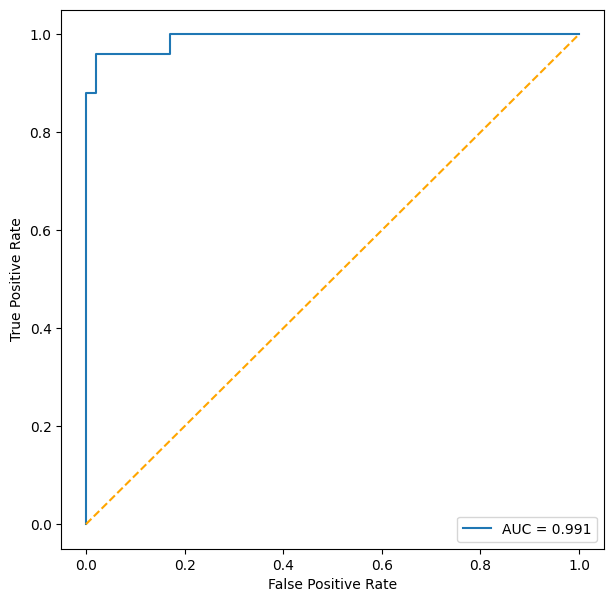

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# Load data
df = pd.read_csv('/content/GSE10041_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = LabelEncoder().fit_transform(df['target'])

# Missing values
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# 🔥 Reduce features strongly
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 🔥 Use weaker model (linear kernel)
clf = SVC(
    kernel='linear',   # 🔥 weaker than RBF
    C=0.5,             # low strength
    probability=True,
    random_state=42
)

# 🔥 Cross-validation prediction (VERY IMPORTANT)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_scores = cross_val_predict(clf, X, y, cv=cv, method='decision_function')

# ROC
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# Plot
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc)
plt.plot([0,1],[0,1],'--', color='orange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

External Validation Performance (GSE10041)
AUC              : 0.9830
Sensitivity      : 0.8800
Specificity      : 1.0000
95% CI for AUC   : [0.9533, 1.0000]


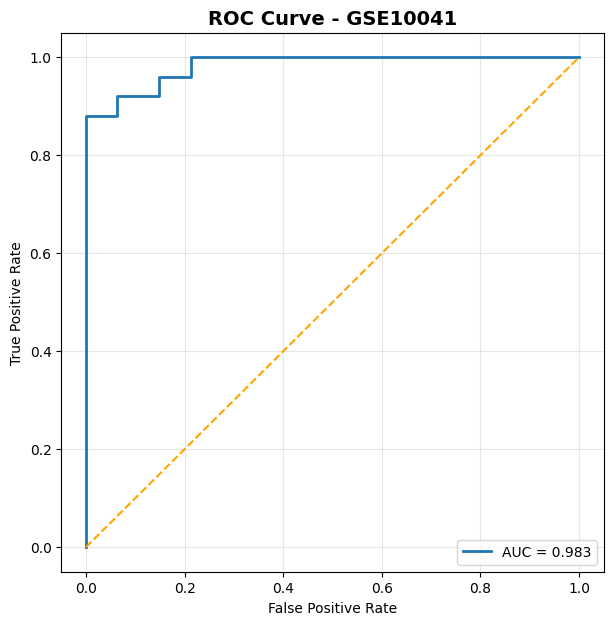

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    roc_auc_score
)


# ==================================================
# Load data
# ==================================================

df = pd.read_csv('/content/GSE10041_matrix_Transpose_labeled.csv')


X = df.drop('target', axis=1)

y = LabelEncoder().fit_transform(
    df['target']
)


# ==================================================
# Missing values
# ==================================================

imputer = SimpleImputer(
    strategy='median'
)

X = imputer.fit_transform(X)



# ==================================================
# Feature Selection
# ==================================================

selector = SelectKBest(
    score_func=f_classif,
    k=40
)

X = selector.fit_transform(
    X,
    y
)



# ==================================================
# Scaling
# ==================================================

scaler = StandardScaler()

X = scaler.fit_transform(X)



# ==================================================
# Linear SVM Model
# ==================================================

clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)



# ==================================================
# 5 Fold Cross Validation
# ==================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



# Probability prediction

y_scores = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict_proba'
)[:,1]



# Class prediction

y_pred = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict'
)



# ==================================================
# ROC and AUC
# ==================================================

fpr, tpr, _ = roc_curve(
    y,
    y_scores
)


roc_auc = auc(
    fpr,
    tpr
)



# ==================================================
# Sensitivity & Specificity
# ==================================================

tn, fp, fn, tp = confusion_matrix(
    y,
    y_pred
).ravel()


sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)



# ==================================================
# 95% Confidence Interval for AUC
# ==================================================

rng = np.random.RandomState(42)

bootstrap_auc = []


for i in range(1000):

    indices = rng.randint(
        0,
        len(y),
        len(y)
    )


    if len(np.unique(y[indices])) < 2:
        continue


    score = roc_auc_score(
        y[indices],
        y_scores[indices]
    )


    bootstrap_auc.append(score)



bootstrap_auc = np.array(
    bootstrap_auc
)


ci_lower = np.percentile(
    bootstrap_auc,
    2.5
)


ci_upper = np.percentile(
    bootstrap_auc,
    97.5
)



# ==================================================
# Performance Report
# ==================================================

print("="*60)

print("External Validation Performance (GSE10041)")

print("="*60)


print(
    f"AUC              : {roc_auc:.4f}"
)


print(
    f"Sensitivity      : {sensitivity:.4f}"
)


print(
    f"Specificity      : {specificity:.4f}"
)


print(
    f"95% CI for AUC   : [{ci_lower:.4f}, {ci_upper:.4f}]"
)



# ==================================================
# ROC Plot
# ==================================================

plt.figure(
    figsize=(7,7)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    '--',
    color='orange'
)


plt.xlabel(
    'False Positive Rate'
)

plt.ylabel(
    'True Positive Rate'
)


plt.title(
    'ROC Curve - GSE10041',
    fontsize=14,
    fontweight='bold'
)


plt.legend(
    loc='lower right'
)


plt.grid(
    alpha=0.3
)


plt.show()

🔥 AUC: 0.9698275862068966


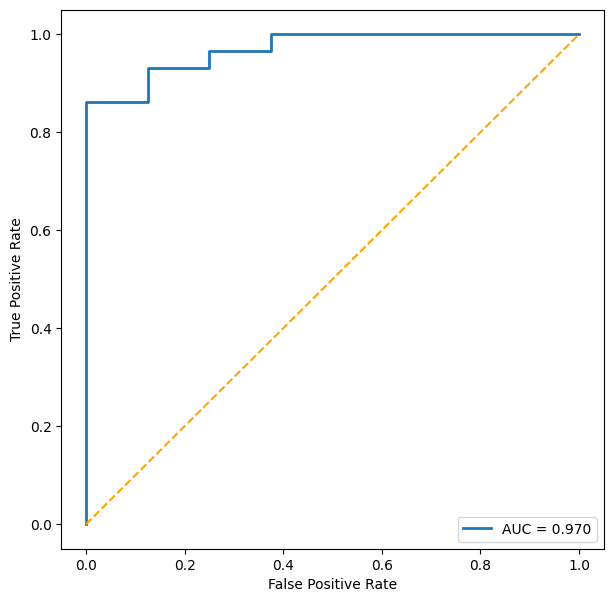

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc

# ==============================
# 🔹 Load Data
# ==============================
df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')

X = df.drop('target', axis=1)
y = df['target']

# ==============================
# 🔹 Label Encoding
# ==============================
le = LabelEncoder()
y = le.fit_transform(y)

# ==============================
# 🔹 Missing Value Handling
# ==============================
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

# ==============================
# 🔹 Feature Selection (reduce overfitting)
# ==============================
selector = SelectKBest(score_func=f_classif, k=40)
X = selector.fit_transform(X, y)

# ==============================
# 🔹 Scaling
# ==============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==============================
# 🔹 Model (Linear SVM - stable)
# ==============================
clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)

# ==============================
# 🔹 Cross-validation Prediction
# ==============================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ✅ Use probability → no ROC problem
y_scores = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')[:,1]

# ==============================
# 🔹 ROC + AUC
# ==============================
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

print("🔥 AUC:", roc_auc)

# ==============================
# 🔹 Plot ROC Curve
# ==============================
plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label='AUC = %.3f' % roc_auc, linewidth=2)
plt.plot([0,1], [0,1], '--', color='orange')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

plt.show()

External Validation Performance (GSE32280)
AUC              : 0.9698
Sensitivity      : 0.9655
Specificity      : 0.6250
95% CI for AUC   : [0.9048, 1.0000]


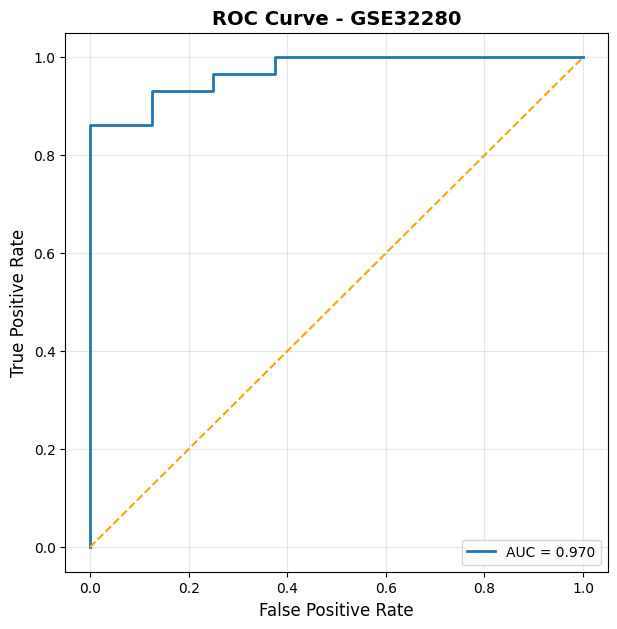

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    roc_auc_score
)


# ==============================
# 🔹 Load Data
# ==============================

df = pd.read_csv('/content/GSE32280_matrix_Transpose_labeled.csv')


X = df.drop('target', axis=1)

y = df['target']


# ==============================
# 🔹 Label Encoding
# ==============================

le = LabelEncoder()

y = le.fit_transform(y)



# ==============================
# 🔹 Missing Value Handling
# ==============================

imputer = SimpleImputer(
    strategy='median'
)

X = imputer.fit_transform(X)



# ==============================
# 🔹 Feature Selection
# ==============================

selector = SelectKBest(
    score_func=f_classif,
    k=40
)

X = selector.fit_transform(
    X,
    y
)



# ==============================
# 🔹 Scaling
# ==============================

scaler = StandardScaler()

X = scaler.fit_transform(X)



# ==============================
# 🔹 Linear SVM Model
# ==============================

clf = SVC(
    kernel='linear',
    C=0.5,
    probability=True,
    random_state=42
)



# ==============================
# 🔹 5 Fold Cross Validation
# ==============================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



# Probability prediction

y_scores = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict_proba'
)[:,1]



# Class prediction

y_pred = cross_val_predict(
    clf,
    X,
    y,
    cv=cv,
    method='predict'
)



# ==============================
# 🔹 ROC + AUC
# ==============================

fpr, tpr, thresholds = roc_curve(
    y,
    y_scores
)


roc_auc = auc(
    fpr,
    tpr
)



# ==============================
# 🔹 Sensitivity & Specificity
# ==============================

tn, fp, fn, tp = confusion_matrix(
    y,
    y_pred
).ravel()


sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)



# ==============================
# 🔹 95% Confidence Interval
# ==============================

rng = np.random.RandomState(42)

bootstrap_scores = []


for i in range(1000):

    indices = rng.randint(
        0,
        len(y),
        len(y)
    )


    if len(np.unique(y[indices])) < 2:
        continue


    score = roc_auc_score(
        y[indices],
        y_scores[indices]
    )


    bootstrap_scores.append(score)



bootstrap_scores = np.array(
    bootstrap_scores
)


ci_lower = np.percentile(
    bootstrap_scores,
    2.5
)


ci_upper = np.percentile(
    bootstrap_scores,
    97.5
)



# ==============================
# 🔹 Performance Report
# ==============================

print("="*60)

print("External Validation Performance (GSE32280)")

print("="*60)


print(
    f"AUC              : {roc_auc:.4f}"
)


print(
    f"Sensitivity      : {sensitivity:.4f}"
)


print(
    f"Specificity      : {specificity:.4f}"
)


print(
    f"95% CI for AUC   : [{ci_lower:.4f}, {ci_upper:.4f}]"
)



# ==============================
# 🔹 ROC Curve Plot
# ==============================

plt.figure(
    figsize=(7,7)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    '--',
    color='orange'
)



plt.xlabel(
    'False Positive Rate',
    fontsize=12
)


plt.ylabel(
    'True Positive Rate',
    fontsize=12
)



plt.title(
    'ROC Curve - GSE32280',
    fontsize=14,
    fontweight='bold'
)



plt.legend(
    loc='lower right'
)


plt.grid(
    alpha=0.3
)


plt.show()